## Dados já carregados

In [1]:
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)
import pandas as pd
import polars as pl
pd.set_option('future.no_silent_downcasting', True)
import numpy as np
import joblib
import gc
from funcoes_de_treinamento import *
inst = joblib.load("../scalers/instituicoes_validas.joblib")


windows = ["7-1", "7-2", "14-1", "14-3", "30-7"]
w = windows[1]
if w == windows[0]:
    inputs_day = 7
    outputs_day = 1
    inputs_hour = 7*24
    outputs_hour = 1*24
    inputs_10min = 7*24*6
    outputs_10min = 1*24*6
elif w == windows[1]:
    inputs_day = 7
    outputs_day = 2
    inputs_hour = 7*24
    outputs_hour = 2*24
    inputs_10min = 7*24*6
    outputs_10min = 2*24*6
elif w == windows[2]:
    inputs_day = 14
    outputs_day = 1
    inputs_hour = 14*24
    outputs_hour = 1*24
    inputs_10min = 14*24*6
    outputs_10min = 1*24*6
elif w == windows[3]:
    inputs_day = 14
    outputs_day = 3
    inputs_hour = 14*24
    outputs_hour = 3*24
    inputs_10min = 14*24*6
    outputs_10min = 3*24*6
elif w == windows[4]:
    inputs_day = 30
    outputs_day = 7
    inputs_hour = 30*24
    outputs_hour = 7*24
    inputs_10min = 30*24*6
    outputs_10min = 7*24*6


2026-04-28 12:08:57.404026: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-28 12:08:57.405761: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 12:08:57.933137: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-28 12:08:59.133032: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

### Dia

In [2]:


train_day_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/treino_day.csv')
test_day_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/teste_day.csv')
val_day_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/val_day.csv')


np_train_d = train_day_wind.to_numpy()
np_test_d = test_day_wind.to_numpy()
np_val_d = val_day_wind.to_numpy()
del train_day_wind, test_day_wind, val_day_wind
X_train_d = np_train_d[:, :inputs_day + 1].astype('float32')
y_train_d = np_train_d[:, inputs_day+1:].astype('float32')
del np_train_d
X_test_d = np_test_d[:, :inputs_day + 1].astype('float32')
y_test_d = np_test_d[:, np.r_[inputs_day+1:inputs_day+1+y_train_d.shape[1],0]].astype('float32')
del np_test_d
X_val_d = np_val_d[:, :inputs_day + 1].astype('float32')
y_val_d = np_val_d[:, inputs_day+1:].astype('float32')
del np_val_d

gc.collect()

56

### Hora

In [3]:
train_hour_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/treino_hour.csv')
test_hour_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/teste_hour.csv')
val_hour_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/val_hour.csv')

np_train_h = train_hour_wind.to_numpy()
np_test_h = test_hour_wind.to_numpy()
np_val_h = val_hour_wind.to_numpy()
del train_hour_wind, test_hour_wind, val_hour_wind
X_train_h = np_train_h[:, :inputs_hour + 1].astype('float32')
y_train_h = np_train_h[:, inputs_hour+1:].astype('float32')
del np_train_h
X_test_h = np_test_h[:, :inputs_hour + 1].astype('float32')
y_test_h = np_test_h[:, np.r_[inputs_hour+1:inputs_hour+1+y_train_h.shape[1],0]].astype('float32')
del np_test_h
X_val_h = np_val_h[:, :inputs_hour + 1].astype('float32')
y_val_h = np_val_h[:, inputs_hour+1:].astype('float32')
del np_val_h

gc.collect()

0

### Minuto

In [4]:
train_10min_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/treino_10min.csv')
test_10min_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/teste_10min.csv')
val_10min_wind = pl.read_csv('../../data/Tabelas_criadas/' + w + '/val_10min.csv')


np_train_10m = train_10min_wind.to_numpy()
del train_10min_wind
np_test_10m = test_10min_wind.to_numpy()
del test_10min_wind
np_val_10m = val_10min_wind.to_numpy()
del val_10min_wind
X_train_10m = np_train_10m[:, :inputs_10min + 1].astype('float32')
y_train_10m = np_train_10m[:, inputs_10min+1:].astype('float32')
del np_train_10m
X_test_10m = np_test_10m[:, :inputs_10min + 1].astype('float32')
y_test_10m= np_test_10m[:, np.r_[inputs_10min+1:inputs_10min+1+y_train_10m.shape[1],0]].astype('float32')
del np_test_10m
X_val_10m = np_val_10m[:, :inputs_10min + 1].astype('float32')
y_val_10m = np_val_10m[:, inputs_10min+1:].astype('float32')
del np_val_10m



gc.collect()

0

## Treino de modelos

criando modelo...


E0000 00:00:1777380726.993249 2957177 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777380727.001018 2957177 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.07748375087976456   val:0.07641797512769699            
MAE:
    teste:0.0383530929684639   val:0.035459309816360474            
NRMSE:
  teste:0.07654599845409393   val:0.06569093465805054            
SMAPE:
  teste:58.74029541015625   val:54.53998947143555


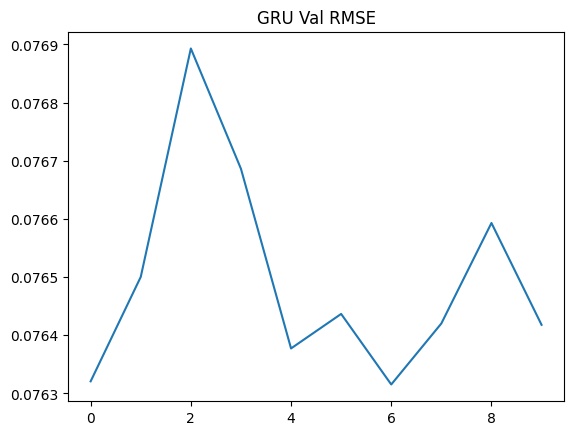

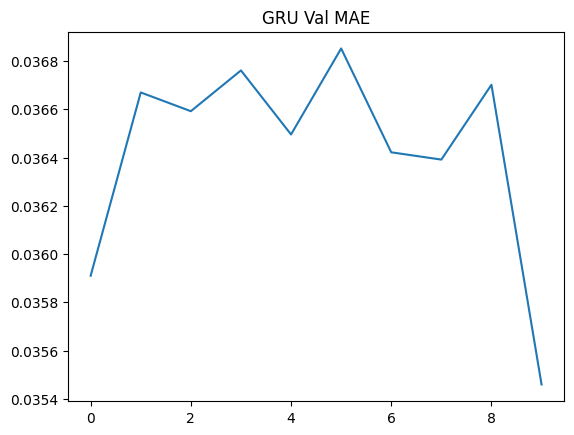

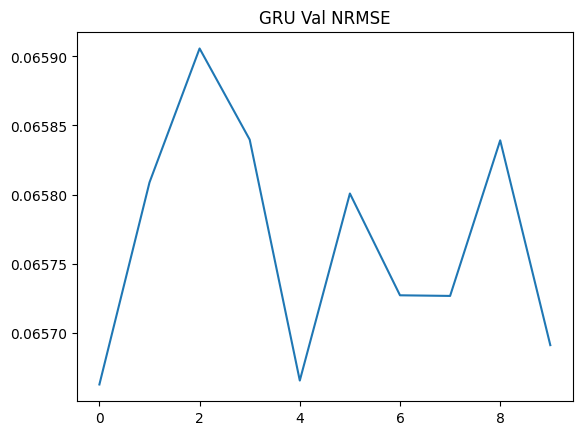

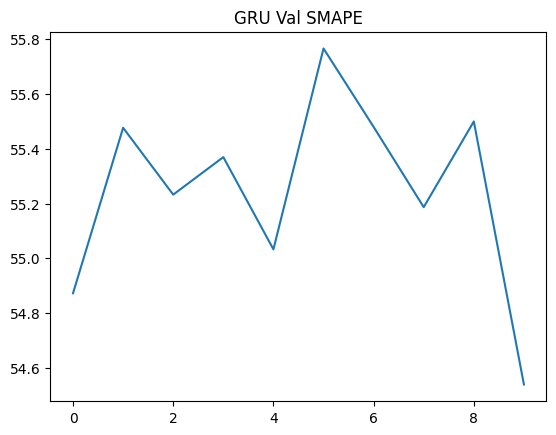

In [5]:

gru_10m_ = criar_e_treinarGRU(
    dimensao="10minutos",
    input_len=inputs_10min,
    output_len=outputs_10min,
    X_train=X_train_10m[:,1:],
    y_train=y_train_10m,
    X_val=X_val_10m[:,1:],
    y_val=y_val_10m,
    epochs=10,
    batch_size=16,
    dropout_rate=0.3270035866295655,
    gru_units=66,
    path_modelo=f'{w}/gru_10min_otimizada_sem_id.keras',
    plot=True,
    verbose=True
)

criando modelo...
compilando modelo...
treinando modelo...


E0000 00:00:1777389034.102908 3000499 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777389034.111340 3000499 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


modelo treinado!            
Resultado:            
RMSE:
   teste:0.07757871598005295   val:0.07650547474622726            
MAE:
    teste:0.03840198740363121   val:0.03733515739440918            
NRMSE:
  teste:0.0766151174902916   val:0.06585614383220673            
SMAPE:
  teste:58.66345977783203   val:56.02363586425781


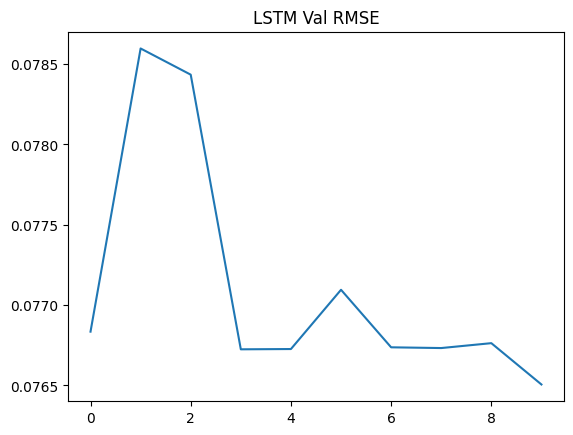

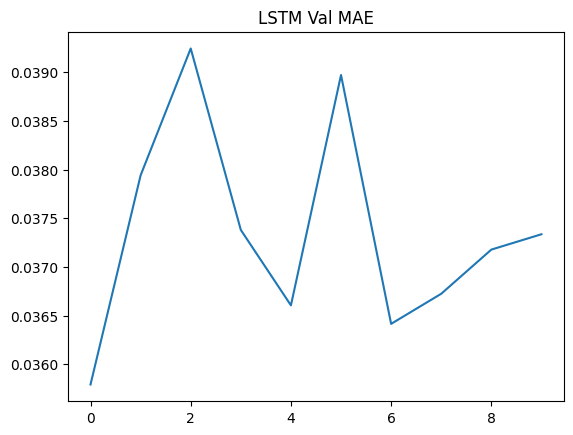

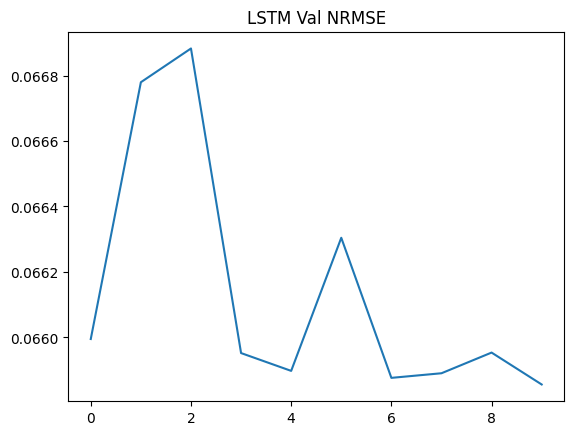

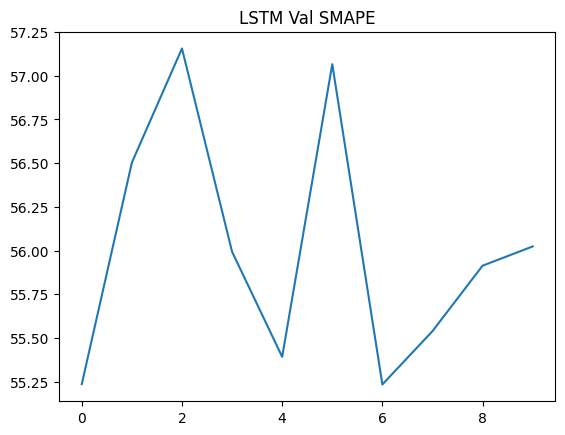

In [ ]:
lstm_10m_ = criar_e_treinarLSTM(
    dimensao="10minutos",
    input_len=inputs_10min,
    output_len=outputs_10min,     
    X_train=X_train_10m[:,1:],
    y_train=y_train_10m,
    X_val=X_val_10m[:,1:],
    y_val=y_val_10m,
    epochs=10,
    batch_size=16,
    dropout_rate=0.3270035866295655,
    lstm_units=66,
    path_modelo=f'{w}/lstm_10min_otimizada_sem_id.keras',
    plot=True,
    verbose=True
)

criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.07808985561132431   val:0.07737451791763306                
MAE:
    teste:0.038516104221343994   val:0.03598237782716751                
NRMSE:
  teste:0.07718860357999802   val:0.0665937215089798                
SMAPE:
  teste:58.44784164428711   val:56.890281677246094


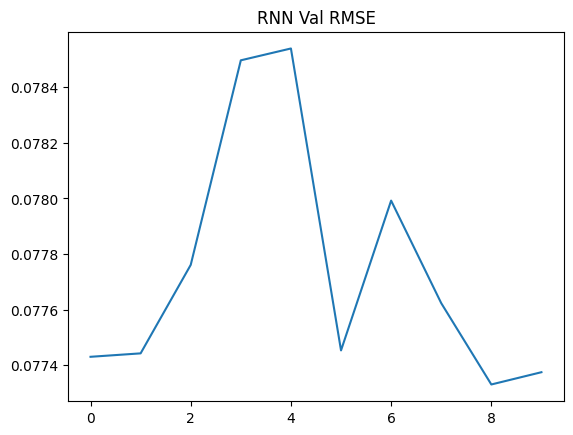

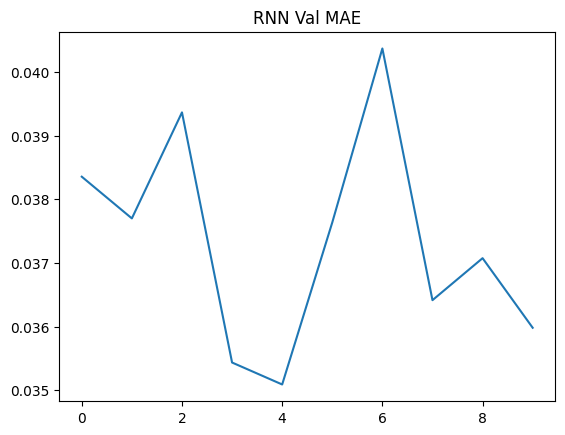

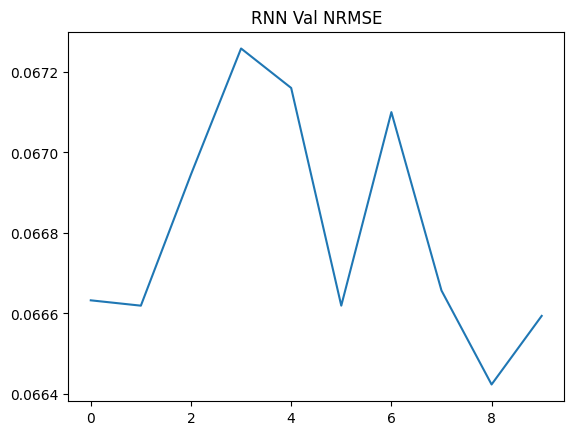

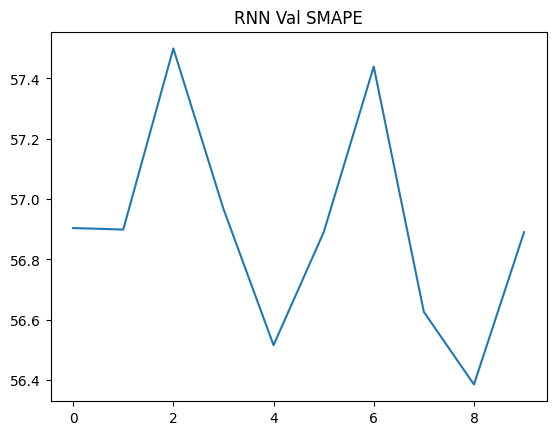

In [6]:
rnn_10m_ = criar_e_treinarRNN(
    dimensao="10minutos",
    input_len=inputs_10min,
    output_len=outputs_10min,
    X_train=X_train_10m[:,1:],
    y_train=y_train_10m,
    X_val=X_val_10m[:,1:],
    y_val=y_val_10m,
    epochs=10,
    batch_size=16,
    dropout_rate=0.3270035866295655,
    rnn_units=66,
    path_modelo=f'{w}/rnn_10min_otimizada_sem_id.keras',
    plot=True,
    verbose=True
)

In [ ]:
lstm_study_10min_sid = otimizar_LSTM(X_train_10m[:,1:], 
                        y_train_10m, 
                        X_val_10m[:,1:], 
                        y_val_10m, 
                        "10minutos", 
                        inputs_10m, 
                        outputs_10m,
                        path_modelo='lstm_10min_otimizada_sem_id.keras')

In [ ]:
rnn_study_10min_sid = otimizar_RNN(X_train_10m[:,1:], 
                        y_train_10m, 
                        X_val_10m[:,1:], 
                        y_val_10m, 
                        "10minutos", 
                        inputs_10m, 
                        outputs_10m,
                        path_modelo='rnn_10min_otimizada_sem_id.keras')

[I 2026-04-22 16:11:21,182] A new study created in memory with name: Otimizacao_GRU


criando modelo...
compilando modelo...
treinando modelo...
Epoch 1/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0801 - mae: 0.2308 - nrmse: 0.2784 - rmse: 0.2830 - smape: 39.9515 - val_loss: 0.0633 - val_mae: 0.2098 - val_nrmse: 0.2497 - val_rmse: 0.2516 - val_smape: 34.6826
Epoch 2/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0654 - mae: 0.2145 - nrmse: 0.2549 - rmse: 0.2557 - smape: 35.0244 - val_loss: 0.0633 - val_mae: 0.2101 - val_nrmse: 0.2496 - val_rmse: 0.2517 - val_smape: 34.4688
Epoch 3/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0644 - mae: 0.2125 - nrmse: 0.2532 - rmse: 0.2539 - smape: 34.5673 - val_loss: 0.0630 - val_mae: 0.2099 - val_nrmse: 0.2491 - val_rmse: 0.2511 - val_smape: 34.5477
Epoch 4/10
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0635 - mae: 0.2109 - nrmse: 0.2512 - rmse: 0.2519 - smape: 34.3668 - val_loss: 0.0629 - val_mae: 0.2099 - val_nrmse: 0.2489 - val_rmse: 0.2509 - val_smape: 34.4390
Epoch 5/10
101/101 ━━━━━━━━━━━━━━━━━━

[I 2026-04-22 16:11:23,914] Trial 0 finished with value: 0.24860814213752747 and parameters: {'batch_size': 32, 'epochs': 10, 'dropout_rate': 0.27404404923650205, 'gru_units': 55}. Best is trial 0 with value: 0.24860814213752747.


criando modelo...
compilando modelo...
treinando modelo...
Epoch 1/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0689 - mae: 0.2174 - nrmse: 0.2593 - rmse: 0.2625 - smape: 36.2995 - val_loss: 0.0643 - val_mae: 0.2116 - val_nrmse: 0.2494 - val_rmse: 0.2536 - val_smape: 34.7118
Epoch 2/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0633 - mae: 0.2111 - nrmse: 0.2504 - rmse: 0.2515 - smape: 34.3968 - val_loss: 0.0634 - val_mae: 0.2101 - val_nrmse: 0.2479 - val_rmse: 0.2518 - val_smape: 33.7850
Epoch 3/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0628 - mae: 0.2110 - nrmse: 0.2492 - rmse: 0.2507 - smape: 34.2601 - val_loss: 0.0631 - val_mae: 0.2099 - val_nrmse: 0.2473 - val_rmse: 0.2512 - val_smape: 34.2541
Epoch 4/10
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0625 - mae: 0.2100 - nrmse: 0.2488 - rmse: 0.2500 - smape: 34.0847 - val_loss: 0.0630 - val_mae: 0.2101 - val_nrmse: 0.2471 - val_rmse: 0.2510 - val_smape: 34.5178
Epoch 5/10
202/202 ━━━━━━━━━━━━━━━━━━

[I 2026-04-22 16:11:27,479] Trial 1 finished with value: 0.24646203219890594 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.21736875059768074, 'gru_units': 94}. Best is trial 1 with value: 0.24646203219890594.


...

criando modelo...
compilando modelo...
treinando modelo...
Epoch 1/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0847 - mae: 0.2366 - nrmse: 0.2856 - rmse: 0.2910 - smape: 39.9390 - val_loss: 0.0635 - val_mae: 0.2102 - val_nrmse: 0.2480 - val_rmse: 0.2520 - val_smape: 34.7652
Epoch 2/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0672 - mae: 0.2166 - nrmse: 0.2576 - rmse: 0.2592 - smape: 35.2482 - val_loss: 0.0626 - val_mae: 0.2092 - val_nrmse: 0.2463 - val_rmse: 0.2501 - val_smape: 34.0998
Epoch 3/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0667 - mae: 0.2159 - nrmse: 0.2567 - rmse: 0.2583 - smape: 35.0434 - val_loss: 0.0631 - val_mae: 0.2100 - val_nrmse: 0.2474 - val_rmse: 0.2513 - val_smape: 34.3545
Epoch 4/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0652 - mae: 0.2140 - nrmse: 0.2541 - rmse: 0.2553 - smape: 34.6786 - val_loss: 0.0631 - val_mae: 0.2102 - val_nrmse: 0.2473 - val_rmse: 0.2512 - val_smape: 34.5307
Epoch 5/30
202/202 ━━━━━━━━━━━━━━━━━━

[I 2026-04-22 16:13:17,914] Trial 18 finished with value: 0.24627819657325745 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.4954910614285646, 'gru_units': 39}. Best is trial 12 with value: 0.2462649941444397.


criando modelo...
compilando modelo...
treinando modelo...
Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1407 - mae: 0.2999 - nrmse: 0.3629 - rmse: 0.3751 - smape: 57.2052 - val_loss: 0.0653 - val_mae: 0.2127 - val_nrmse: 0.2531 - val_rmse: 0.2555 - val_smape: 34.7702
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0724 - mae: 0.2230 - nrmse: 0.2686 - rmse: 0.2691 - smape: 36.0381 - val_loss: 0.0643 - val_mae: 0.2116 - val_nrmse: 0.2512 - val_rmse: 0.2537 - val_smape: 34.5589
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0696 - mae: 0.2187 - nrmse: 0.2636 - rmse: 0.2638 - smape: 35.7011 - val_loss: 0.0636 - val_mae: 0.2107 - val_nrmse: 0.2498 - val_rmse: 0.2523 - val_smape: 34.2598
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0680 - mae: 0.2166 - nrmse: 0.2605 - rmse: 0.2608 - smape: 35.2502 - val_loss: 0.0633 - val_mae: 0.2104 - val_nrmse: 0.2492 - val_rmse: 0.2517 - val_smape: 34.3407
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

[I 2026-04-22 16:13:22,526] Trial 19 finished with value: 0.24749019742012024 and parameters: {'batch_size': 64, 'epochs': 30, 'dropout_rate': 0.30744751342231563, 'gru_units': 33}. Best is trial 12 with value: 0.2462649941444397.



Melhor NRMSE: 0.2462649941444397
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.18717448523831448, 'gru_units': 102}
criando modelo...
compilando modelo...
treinando modelo...
Epoch 1/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0664 - mae: 0.2145 - nrmse: 0.2557 - rmse: 0.2577 - smape: 35.3460 - val_loss: 0.0640 - val_mae: 0.2112 - val_nrmse: 0.2489 - val_rmse: 0.2529 - val_smape: 34.4144
Epoch 2/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0627 - mae: 0.2104 - nrmse: 0.2489 - rmse: 0.2504 - smape: 34.2771 - val_loss: 0.0639 - val_mae: 0.2109 - val_nrmse: 0.2488 - val_rmse: 0.2527 - val_smape: 33.7209
Epoch 3/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0630 - mae: 0.2111 - nrmse: 0.2496 - rmse: 0.2509 - smape: 34.2414 - val_loss: 0.0629 - val_mae: 0.2096 - val_nrmse: 0.2469 - val_rmse: 0.2508 - val_smape: 33.8598
Epoch 4/30
202/202 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0624 - mae: 0.2098 - nrmse: 0.2484 - rmse: 0.2498 - smape:

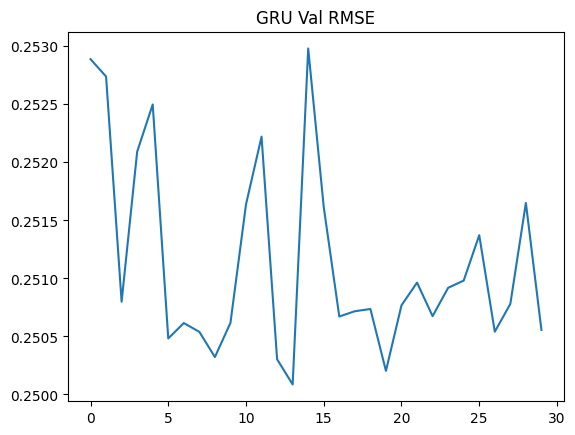

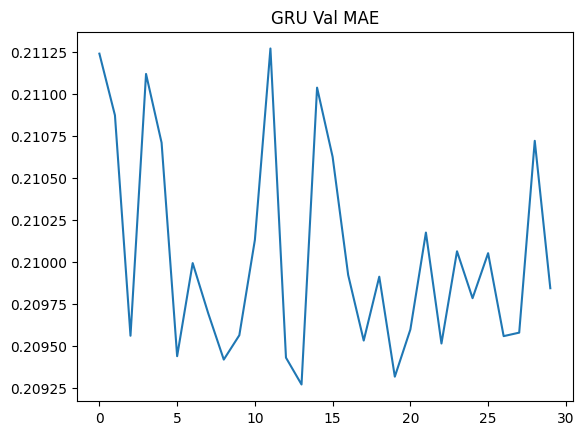

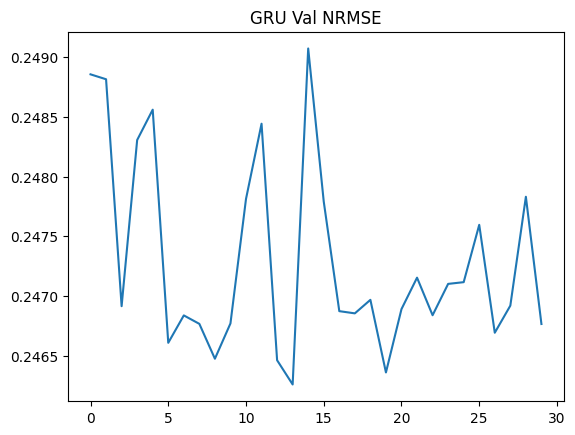

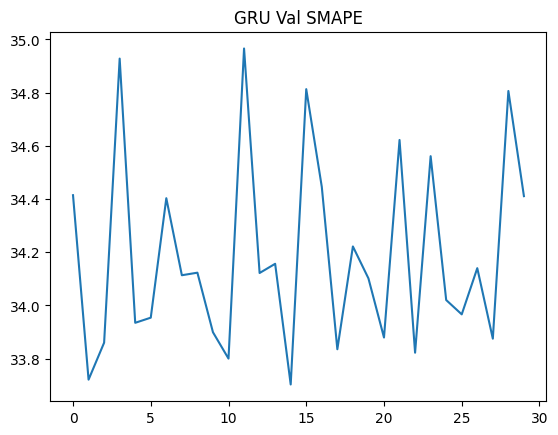

In [6]:
gru_study_d_sid = otimizar_GRU(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária",
                        inputs_day,
                        outputs_day,
                        path_modelo=f'{w}/gru_diaria_otimizada_sem_id.keras')

[I 2026-04-22 16:16:19,613] A new study created in memory with name: Otimizacao_LSTM


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-22 16:16:23,523] Trial 0 finished with value: 0.24842727184295654 and parameters: {'batch_size': 32, 'epochs': 20, 'dropout_rate': 0.33303414968087164, 'lstm_units': 36}. Best is trial 0 with value: 0.24842727184295654.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-22 16:16:29,208] Trial 1 finished with value: 0.24900823831558228 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.12949376049637298, 'lstm_units': 66}. Best is trial 0 with value: 0.24842727184295654.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-22 16:18:11,928] Trial 18 finished with value: 0.24831102788448334 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.25675767822913276, 'lstm_units': 45}. Best is trial 15 with value: 0.2462952435016632.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-22 16:18:17,644] Trial 19 finished with value: 0.24642854928970337 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.3994741310807432, 'lstm_units': 33}. Best is trial 15 with value: 0.2462952435016632.



Melhor NRMSE: 0.2462952435016632
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.4242419873509602, 'lstm_units': 32}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.2484453320503235   val:0.2501238286495209            
MAE:
    teste:0.20939525961875916   val:0.20933257043361664            
NRMSE:
  teste:0.24742788076400757   val:0.2463339865207672            
SMAPE:
  teste:33.96059799194336   val:34.062034606933594


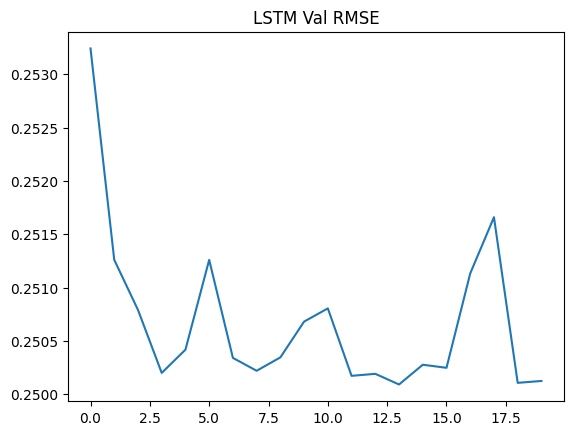

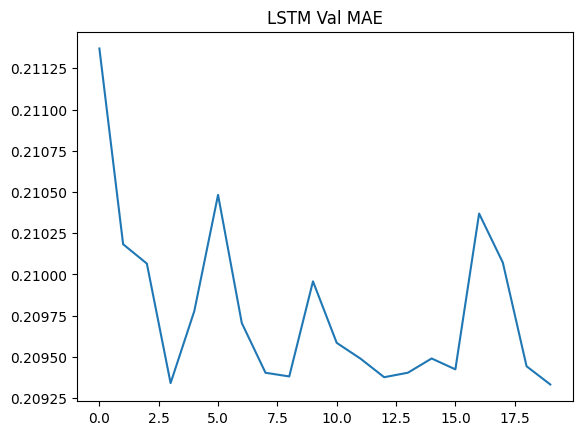

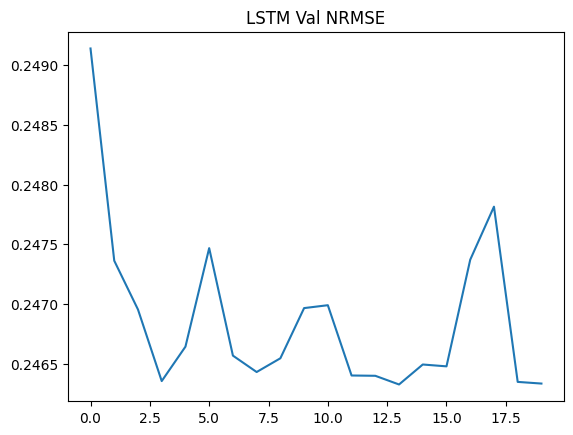

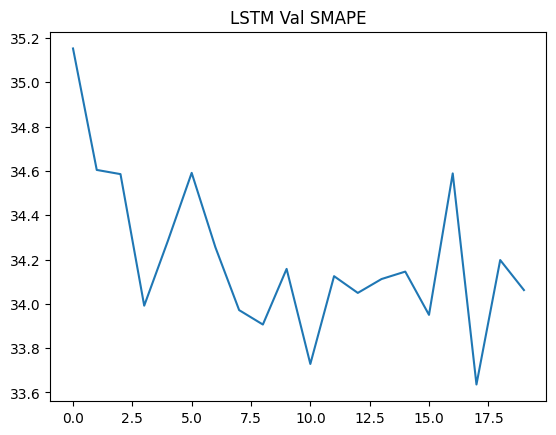

In [7]:
lstm_study_d_sid = otimizar_LSTM(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo=f'{w}/lstm_diaria_otimizada_sem_id.keras'
                        )

In [ ]:
rnn_study_d_sid = otimizar_RNN(X_train_d[:,1:], 
                        y_train_d, 
                        X_val_d[:,1:], 
                        y_val_d, 
                        "diária", 
                        inputs_day, 
                        outputs_day,
                        path_modelo=f'{w}/rnn_diaria_otimizada_sem_id.keras')

In [ ]:
gru_study_h_sid = otimizar_GRU(X_train_h[:,1:], 
                       y_train_h, 
                       X_val_h[:,1:], 
                       y_val_h, 
                       "horária", 
                       inputs_hour,
                       outputs_hour,
                       path_modelo= f'{w}/gru_horaria_otimizada_sem_id.keras')

[I 2026-04-24 13:56:56,653] A new study created in memory with name: Otimizacao_LSTM
E0000 00:00:1777049816.810738 1873638 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777049816.821943 1873638 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 13:57:28,754] Trial 0 finished with value: 0.09504809975624084 and parameters: {'batch_size': 64, 'epochs': 10, 'dropout_rate': 0.14002950459032, 'lstm_units': 109}. Best is trial 0 with value: 0.09504809975624084.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 13:59:29,366] Trial 1 finished with value: 0.09441591799259186 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.1068368822314604, 'lstm_units': 32}. Best is trial 1 with value: 0.09441591799259186.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 14:39:09,041] Trial 18 finished with value: 0.09374258667230606 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.3028019723400932, 'lstm_units': 73}. Best is trial 7 with value: 0.09369786828756332.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 14:39:57,855] Trial 19 finished with value: 0.09490873664617538 and parameters: {'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.4435599713177807, 'lstm_units': 54}. Best is trial 7 with value: 0.09369786828756332.



Melhor NRMSE: 0.09369786828756332
Melhores parâmetros: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.3824534157156064, 'lstm_units': 38}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!            
Resultado:            
RMSE:
   teste:0.10278752446174622   val:0.10258155316114426            
MAE:
    teste:0.06952179968357086   val:0.06981778889894485            
NRMSE:
  teste:0.10213783383369446   val:0.09380079805850983            
SMAPE:
  teste:51.8107795715332   val:51.97894287109375


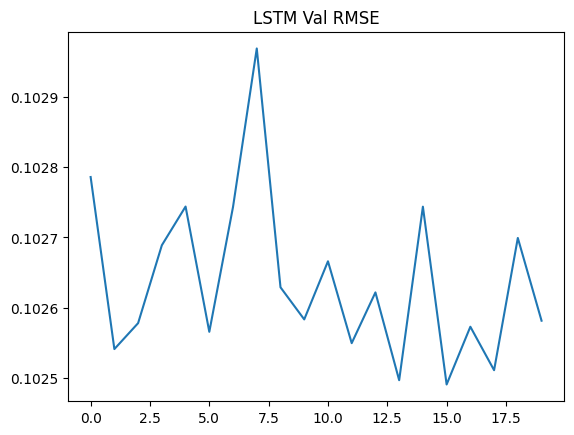

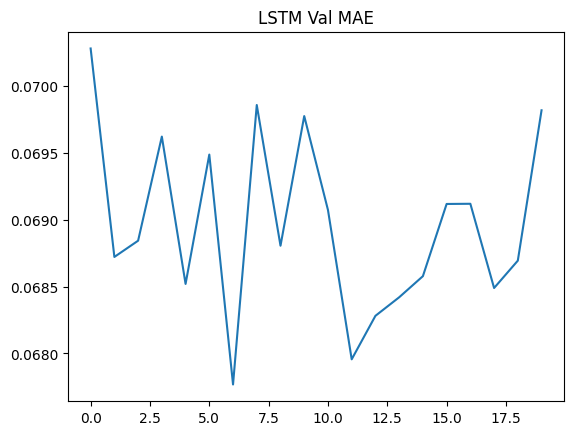

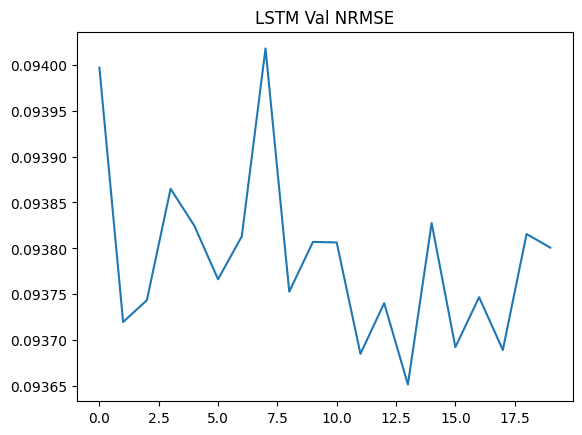

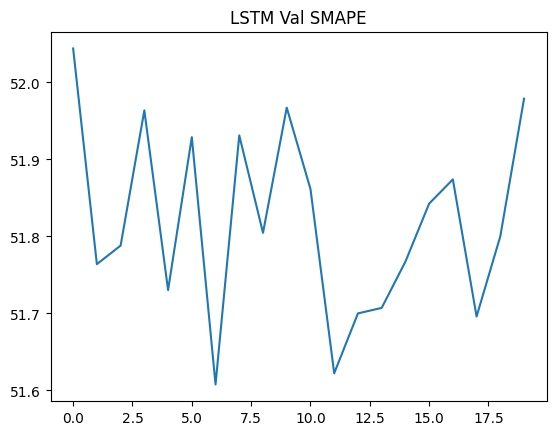

In [ ]:
lstm_study_h_sid = otimizar_LSTM(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:],
                            y_val_h,
                            "horária",
                            inputs_hour,
                            outputs_hour,
                            path_modelo= f'{w}/lstm_horaria_otimizada_sem_id.keras'
)

[I 2026-04-24 15:20:25,665] A new study created in memory with name: Otimizacao_RNN


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 15:21:30,776] Trial 0 finished with value: 0.09423715621232986 and parameters: {'batch_size': 16, 'epochs': 10, 'dropout_rate': 0.28110161566629366, 'rnn_units': 48}. Best is trial 0 with value: 0.09423715621232986.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 15:23:49,813] Trial 1 finished with value: 0.09415068477392197 and parameters: {'batch_size': 16, 'epochs': 20, 'dropout_rate': 0.1994197987374995, 'rnn_units': 82}. Best is trial 1 with value: 0.09415068477392197.


...

criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 15:51:02,105] Trial 18 finished with value: 0.0950075164437294 and parameters: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.45684846033494725, 'rnn_units': 93}. Best is trial 14 with value: 0.09394289553165436.


criando modelo...
compilando modelo...
treinando modelo...


[I 2026-04-24 15:52:55,400] Trial 19 finished with value: 0.0947623923420906 and parameters: {'batch_size': 32, 'epochs': 30, 'dropout_rate': 0.3910426542364718, 'rnn_units': 122}. Best is trial 14 with value: 0.09394289553165436.



Melhor NRMSE: 0.09394289553165436
Melhores parâmetros: {'batch_size': 16, 'epochs': 30, 'dropout_rate': 0.42139885082087275, 'rnn_units': 58}
criando modelo...
compilando modelo...
treinando modelo...
modelo treinado!                
Resultado:                
RMSE:
   teste:0.103379987180233   val:0.10288049280643463                
MAE:
    teste:0.06985849887132645   val:0.0699760764837265                
NRMSE:
  teste:0.10267749428749084   val:0.09407822042703629                
SMAPE:
  teste:51.92707443237305   val:51.94022750854492


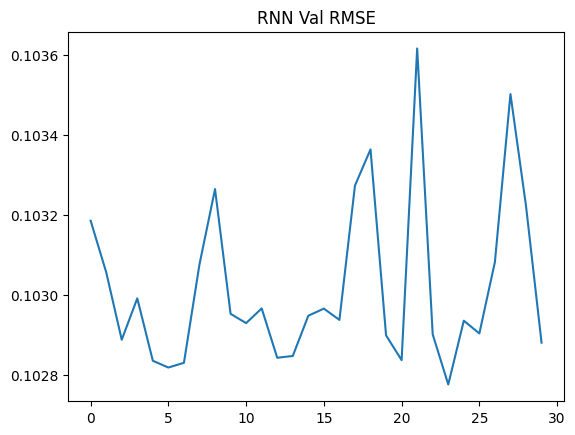

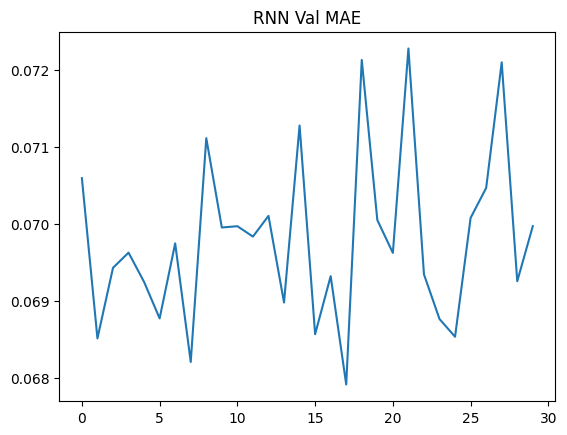

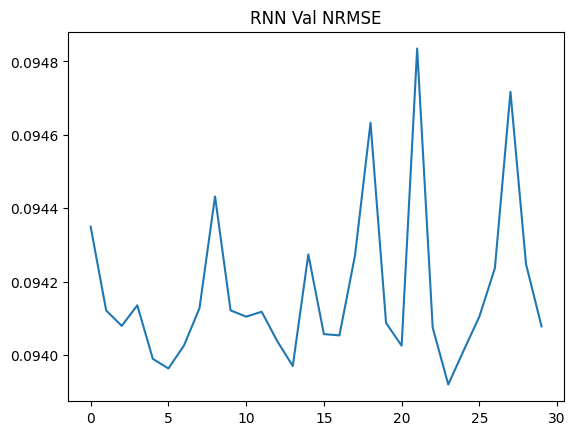

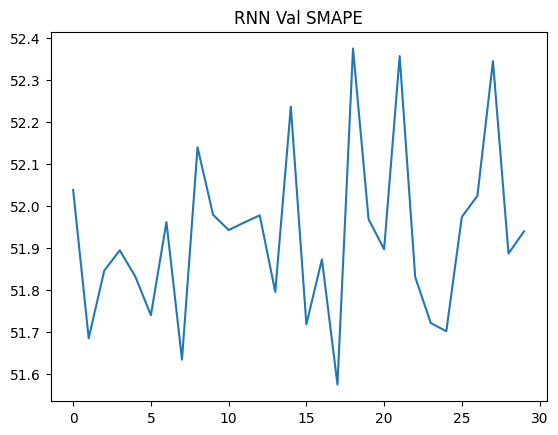

In [ ]:
rnn_study_h_sid = otimizar_RNN(
                          X_train_h[:,1:], 
                          y_train_h, 
                          X_val_h[:,1:], 
                          y_val_h, 
                          "horária", 
                          inputs_hour,
                          outputs_hour,
                          path_modelo= (f'{w}/rnn_horaria_otimizada_sem_id.keras')
)